In [41]:
import pandas as pd
df = pd.read_csv('Downloads\Mini Project Time Series\Time Series - data train.csv')
df

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [10]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [29]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [10]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df[(df["sales"] < batas_bawah) | (df["sales"] > batas_atas)]
print(batas_bawah)
print(batas_atas)
len(outlier)

-293.770875
489.61812499999996


447105

In [9]:
outlier['sales'].values

array([ 810.   ,  700.   , 1091.   , ..., 6630.383,  522.   , 2419.729],
      shape=(447105,))

In [52]:
len(df['family'].unique())

33

In [21]:
pd.Series(df['store_nbr'].unique()).sort_values().count()

np.int64(54)

In [20]:
pd.Series(df['id'].unique()).sort_values().count()

np.int64(3000888)

In [36]:
len(df[df['sales'] == 0]['date'].unique())

1684

In [37]:
sorted(df[df['sales'] == 0]['date'].unique())

['2013-01-01',
 '2013-01-02',
 '2013-01-03',
 '2013-01-04',
 '2013-01-05',
 '2013-01-06',
 '2013-01-07',
 '2013-01-08',
 '2013-01-09',
 '2013-01-10',
 '2013-01-11',
 '2013-01-12',
 '2013-01-13',
 '2013-01-14',
 '2013-01-15',
 '2013-01-16',
 '2013-01-17',
 '2013-01-18',
 '2013-01-19',
 '2013-01-20',
 '2013-01-21',
 '2013-01-22',
 '2013-01-23',
 '2013-01-24',
 '2013-01-25',
 '2013-01-26',
 '2013-01-27',
 '2013-01-28',
 '2013-01-29',
 '2013-01-30',
 '2013-01-31',
 '2013-02-01',
 '2013-02-02',
 '2013-02-03',
 '2013-02-04',
 '2013-02-05',
 '2013-02-06',
 '2013-02-07',
 '2013-02-08',
 '2013-02-09',
 '2013-02-10',
 '2013-02-11',
 '2013-02-12',
 '2013-02-13',
 '2013-02-14',
 '2013-02-15',
 '2013-02-16',
 '2013-02-17',
 '2013-02-18',
 '2013-02-19',
 '2013-02-20',
 '2013-02-21',
 '2013-02-22',
 '2013-02-23',
 '2013-02-24',
 '2013-02-25',
 '2013-02-26',
 '2013-02-27',
 '2013-02-28',
 '2013-03-01',
 '2013-03-02',
 '2013-03-03',
 '2013-03-04',
 '2013-03-05',
 '2013-03-06',
 '2013-03-07',
 '2013-03-

In [46]:
df[df['date'] == '2013-01-01']

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
...,...,...,...,...,...,...
1777,1777,2013-01-01,9,POULTRY,0.0,0
1778,1778,2013-01-01,9,PREPARED FOODS,0.0,0
1779,1779,2013-01-01,9,PRODUCE,0.0,0
1780,1780,2013-01-01,9,SCHOOL AND OFFICE SUPPLIES,0.0,0


In [48]:
df[(df['date'] == '2013-01-01') & (df['sales'] > 0)]

,id,date,store_nbr,family,sales,onpromotion
563,563,2013-01-01,25,BEAUTY,2.000000,0
564,564,2013-01-01,25,BEVERAGES,810.000000,0
566,566,2013-01-01,25,BREAD/BAKERY,180.589000,0
568,568,2013-01-01,25,CLEANING,186.000000,0
569,569,2013-01-01,25,DAIRY,143.000000,0
570,570,2013-01-01,25,DELI,71.090000,0
571,571,2013-01-01,25,EGGS,46.000000,0
572,572,2013-01-01,25,FROZEN FOODS,29.654999,0
573,573,2013-01-01,25,GROCERY I,700.000000,0
574,574,2013-01-01,25,GROCERY II,15.000000,0


In [58]:
df['date'].dt.year.unique()

array([2013, 2014, 2015, 2016, 2017], dtype=int32)

In [59]:
df['date'].dt.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

<Axes: xlabel='date'>

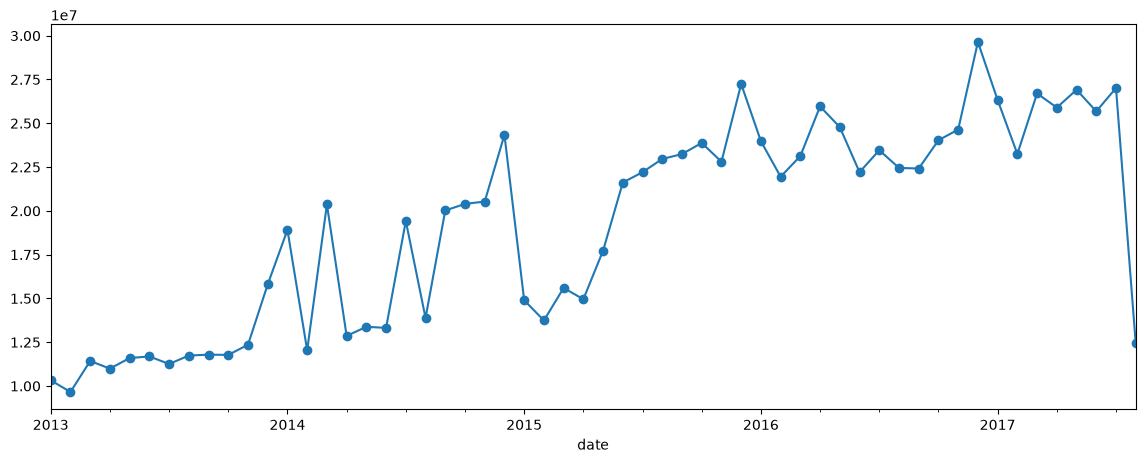

In [60]:
monthly = df.groupby(df['date'].dt.to_period('M'))['sales'].sum()
monthly.index = monthly.index.to_timestamp()
monthly.plot(figsize=(14, 5), marker='o')

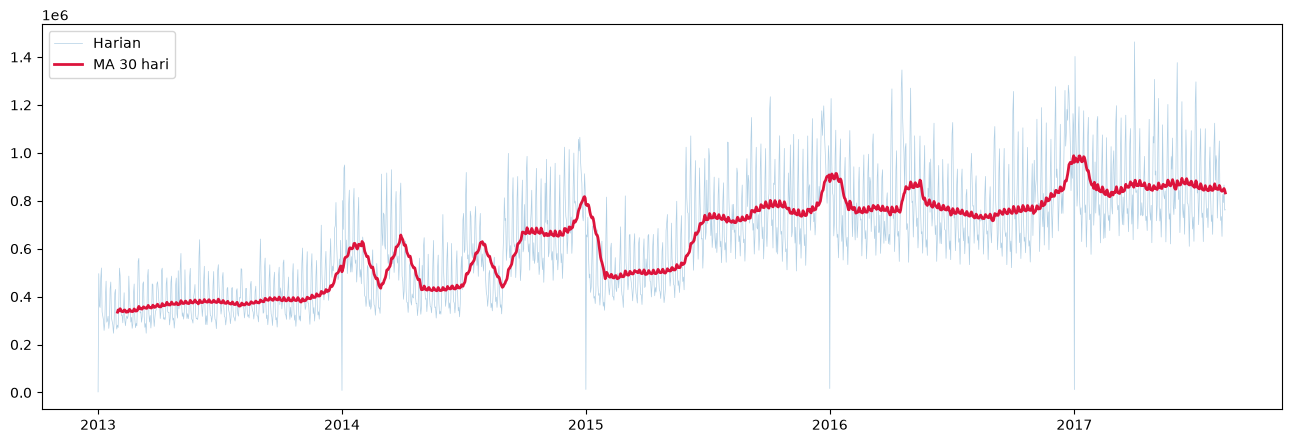

In [61]:
import matplotlib.pyplot as plt

daily = df.groupby('date')['sales'].sum()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily.index, daily, linewidth=0.5, alpha=0.35, label='Harian')
ax.plot(daily.index, daily.rolling(30).mean(), linewidth=2, color='crimson', label='MA 30 hari')
ax.legend()

In [62]:
jan1 = df[(df['date'].dt.month == 1) & (df['date'].dt.day == 1)]
per_store = jan1.groupby('store_nbr')['sales'].sum()
print(per_store[per_store > 0])   # toko yang tetap ada penjualan
print((per_store == 0).sum(), "toko nol penjualan")

store_nbr
25    48793.665376
36     3609.531004
Name: sales, dtype: float64
52 toko nol penjualan


In [63]:
# 1 baris = 1 toko pada 1 hari (total semua kategori)
store_day = df.groupby(['date', 'store_nbr'])['sales'].sum().reset_index()
store_day['closed'] = store_day['sales'] == 0

In [64]:
summary = store_day.groupby('date').agg(
    n_store=('store_nbr', 'nunique'),
    n_closed=('closed', 'sum')
)
summary['all_closed'] = summary['n_closed'] == summary['n_store']

print(summary[summary['all_closed']])          # tanggal seluruh toko tutup
print(summary.sort_values('n_closed', ascending=False).head(20))  # tutup paling banyak

Empty DataFrame
Columns: [n_store, n_closed, all_closed]
Index: []
            n_store  n_closed  all_closed
date                                     
2013-01-01       54        53       False
2016-01-01       54        53       False
2017-01-01       54        53       False
2015-01-01       54        53       False
2014-01-01       54        52       False
2013-07-15       54         8       False
2013-01-02       54         8       False
2013-07-08       54         8       False
2013-07-09       54         8       False
2013-07-11       54         8       False
2013-07-12       54         8       False
2013-07-13       54         8       False
2013-07-14       54         8       False
2013-07-16       54         8       False
2013-05-07       54         8       False
2013-07-17       54         8       False
2013-07-18       54         8       False
2013-07-19       54         8       False
2013-07-20       54         8       False
2013-07-21       54         8       False


In [65]:
store_day[store_day['closed']].groupby('store_nbr').size().sort_values(ascending=False)

store_nbr
52    1566
22    1011
42     962
21     934
29     808
20     773
53     515
36     131
18     115
24     106
25      66
12      65
14      43
30      28
43       9
17       7
1        6
34       5
41       5
44       5
45       5
46       5
40       5
47       5
48       5
39       5
38       5
37       5
49       5
50       5
51       5
35       5
28       5
33       5
11       5
3        5
4        5
5        5
6        5
7        5
8        5
9        5
10       5
13       5
32       5
15       5
16       5
19       5
23       5
26       5
27       5
2        5
31       5
54       5
dtype: int64

<Axes: title={'center': 'Jumlah toko tutup per hari'}, xlabel='date'>

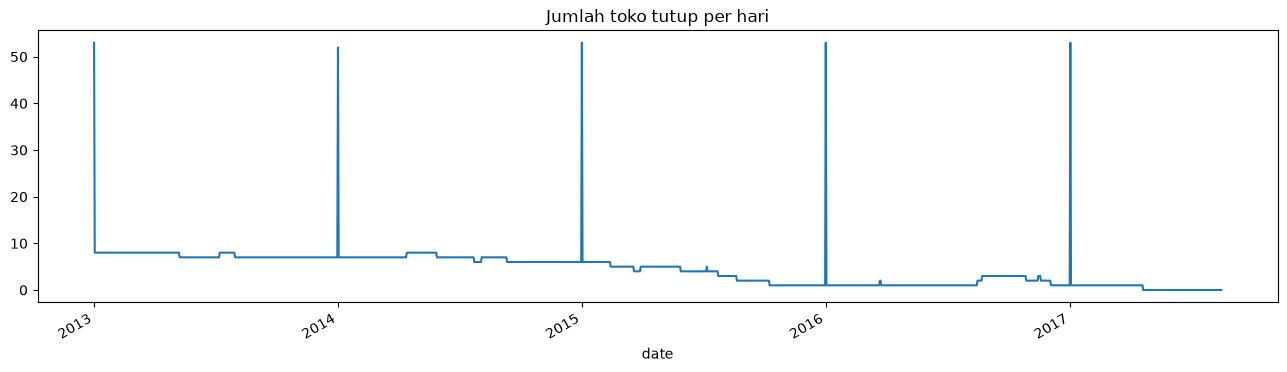

In [66]:
summary['n_closed'].plot(figsize=(16, 4), title='Jumlah toko tutup per hari')

In [68]:
# ambil hanya baris 1 Januari, yang penjualannya > 0 (toko buka)
jan1_open = store_day[
    (store_day['date'].dt.month == 1) &
    (store_day['date'].dt.day == 1) &
    (store_day['sales'] > 0)
]

print(jan1_open[['date', 'store_nbr', 'sales']].sort_values('date'))

            date  store_nbr         sales
24    2013-01-01         25   2511.618999
19680 2014-01-01         25   4992.534400
19691 2014-01-01         36   3609.531004
39336 2015-01-01         25  12773.616980
58992 2016-01-01         25  16433.394000
78702 2017-01-01         25  12082.500997


In [69]:
# tanggal pertama tiap toko punya penjualan > 0
first_sale = (
    df[df['sales'] > 0]
    .groupby('store_nbr')['date']
    .min()
    .sort_values()
)
print(first_sale)

store_nbr
25   2013-01-01
28   2013-01-02
30   2013-01-02
31   2013-01-02
32   2013-01-02
33   2013-01-02
34   2013-01-02
35   2013-01-02
37   2013-01-02
38   2013-01-02
39   2013-01-02
1    2013-01-02
41   2013-01-02
43   2013-01-02
44   2013-01-02
45   2013-01-02
46   2013-01-02
47   2013-01-02
48   2013-01-02
49   2013-01-02
50   2013-01-02
51   2013-01-02
26   2013-01-02
40   2013-01-02
27   2013-01-02
23   2013-01-02
2    2013-01-02
3    2013-01-02
4    2013-01-02
5    2013-01-02
6    2013-01-02
7    2013-01-02
8    2013-01-02
9    2013-01-02
10   2013-01-02
11   2013-01-02
24   2013-01-02
13   2013-01-02
12   2013-01-02
15   2013-01-02
16   2013-01-02
17   2013-01-02
18   2013-01-02
19   2013-01-02
14   2013-01-02
54   2013-01-02
36   2013-05-09
53   2014-05-29
20   2015-02-13
29   2015-03-20
21   2015-07-24
42   2015-08-21
22   2015-10-09
52   2017-04-20
Name: date, dtype: datetime64[ns]


In [70]:
first_row = df.groupby('store_nbr')['date'].min()   # baris pertama, tanpa peduli sales

cek = pd.DataFrame({'baris_pertama': first_row, 'jualan_pertama': first_sale})
cek['selisih_hari'] = (cek['jualan_pertama'] - cek['baris_pertama']).dt.days
print(cek.sort_values('jualan_pertama', ascending=False))

          baris_pertama jualan_pertama  selisih_hari
store_nbr                                           
52           2013-01-01     2017-04-20          1570
22           2013-01-01     2015-10-09          1011
42           2013-01-01     2015-08-21           962
21           2013-01-01     2015-07-24           934
29           2013-01-01     2015-03-20           808
20           2013-01-01     2015-02-13           773
53           2013-01-01     2014-05-29           513
36           2013-01-01     2013-05-09           128
39           2013-01-01     2013-01-02             1
31           2013-01-01     2013-01-02             1
32           2013-01-01     2013-01-02             1
33           2013-01-01     2013-01-02             1
34           2013-01-01     2013-01-02             1
35           2013-01-01     2013-01-02             1
37           2013-01-01     2013-01-02             1
38           2013-01-01     2013-01-02             1
1            2013-01-01     2013-01-02        